In [1]:
import os

import numpy as np

from detector_testing_system.characteristic.bias import (
    calculate_bias,
    research_bias,
)
from detector_testing_system.data import filter_trace_factory, load_data
from detector_testing_system.device import run_device
from detector_testing_system.experiment import ExperimentConfig, run_experiment

In [89]:
import time

from vmk_spectrum3_wrapper.data import Data, Meta
from vmk_spectrum3_wrapper.device.device_config import DeviceConfigAuto
from vmk_spectrum3_wrapper.measurement_manager.filters import F
from vmk_spectrum3_wrapper.types import Array, Digit, IP, MilliSecond, U
from vmk_spectrum3_wrapper.units import Units


class FakeDevice:

    def __init__(
        self,
        config: DeviceConfigAuto,
    ) -> None:

        self.config = config

        self.n_times = None
        self.exposure = None
        self.capacity = None
        self.filter = None

    def setup(
        self,
        n_times: int,
        exposure: MilliSecond,
        capacity: int = 1,
        filter: F | None = None,
    ) -> 'FakeDevice':
        
        self.n_times = n_times
        self.exposure = exposure
        self.capacity = capacity
        self.filter = filter

        return self
    
    def read(self) -> Array[U]:
        
        data = Data(
            units=Units.electron,
            intensity=np.array([
                # 5 + 1*self.exposure + (-.01)*self.exposure**2 + np.random.randn(512)/100
                5 + 1*self.exposure + (-10)/(self.exposure**2) + np.random.randn(512)/100
                for _ in range(self.n_times)
            ]),
            meta=Meta(
                exposure=self.exposure,
                capacity=self.capacity,
                started_at=time.perf_counter(),
                finished_at=time.perf_counter(),
            )
        )
        return data


  0%|          | 0/10 [00:00<?, ?it/s]

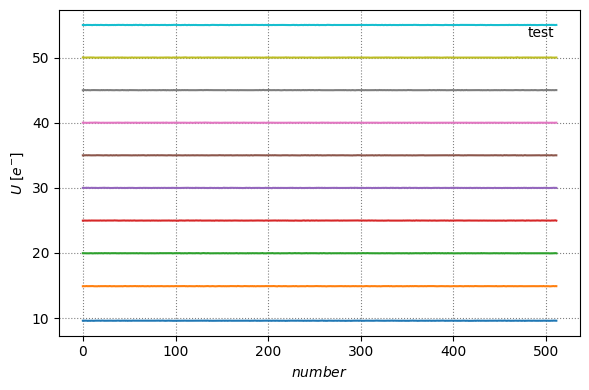

In [90]:
LABEL = 'test'

config = ExperimentConfig.from_ini(LABEL)
device = FakeDevice(
    config=DeviceConfigAuto(),
)

run_experiment(
    device=device,
    config=config,
    params=[
        (100, np.arange(5, 50+5, 5)),
    ],
    label=os.path.join(LABEL, 'bias'),
    force=True,
)
data = load_data(
    label=os.path.join(LABEL, 'bias'),
    show=True,
)

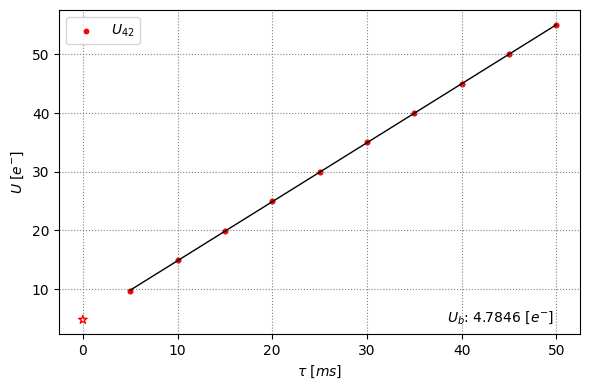

In [91]:
THRESHOLD = (0, 100)
INTERVAL = (0, +np.inf)

bias = calculate_bias(
    trace=data.trace(42),
    filter=filter_trace_factory(
        threshold=THRESHOLD,
        interval=INTERVAL,
    ),
)
bias.show(
    verbose=True,
)

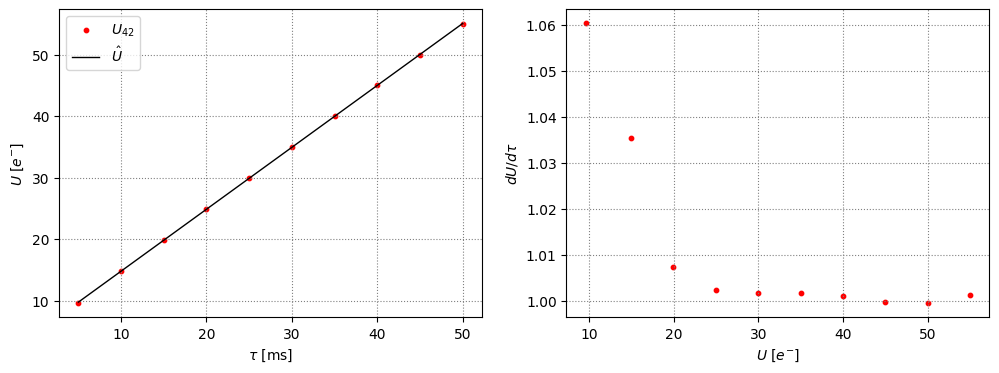

In [92]:
from detector_testing_system.characteristic.gradient import calculate_gradient

gradient = calculate_gradient(
    trace=data.trace(42),
)
gradient.show()

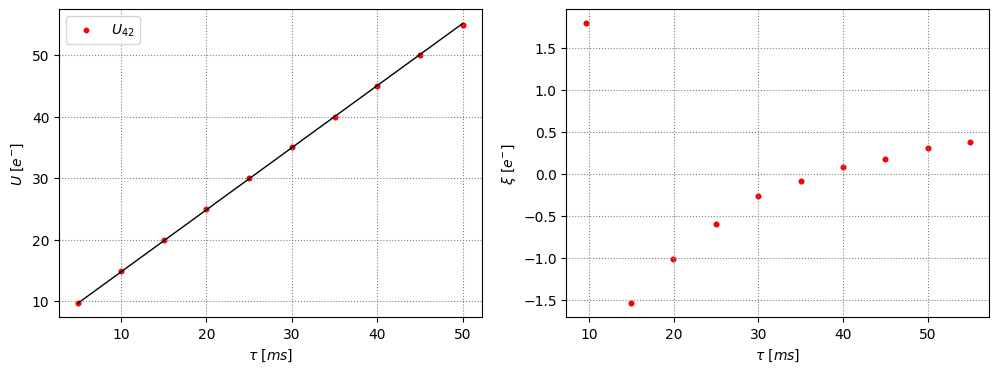

In [93]:
from detector_testing_system.characteristic.dark_current import calculate_dark_current
from detector_testing_system.characteristic.dark_current import (
    BaseDarkCurrentModel,
    JNormDarkCurrentModel,
)
from detector_testing_system.data import filter_trace_factory


dark_current = calculate_dark_current(
    trace=data.trace(42),
    # model=BaseDarkCurrentModel(
    #     weighted=True,
    #     filter=filter_trace_factory(
    #         threshold=(0, 20),
    #     ),
    # ),
    model=JNormDarkCurrentModel(),
)
dark_current.show()

In [82]:
dark_current.value

1.000579263251772